logistic regression 


In [2]:
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

In [3]:
data_path = r"d:\smartnest.ai\dataset\House_Rent_Dataset_TN_synthetic_text_1500.csv"
df = pd.read_csv(data_path)
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,...,Listing_Description,Amenities_Text,Landmarks_Text,Reviews_Text,Complaints_Text,Lease_Rules_Text,Inquiry_Text,Inspection_Notes_Text,Scam_Flag,Scam_Rationale
0,2022-07-06,2,15000,1100,1 out of 2,super area,medavakkam,chennai,semi-furnished,bachelors,...,2 bhk semi-furnished home of 1100 sq ft (super...,"rainwater harvesting, play area, solar lightin...",near college (3.3 km); near hospital (0.6 km);...,clean and well maintained building. | safe are...,not_applicable,no smoking inside the house. tenant must follo...,looking for a 2 bhk near medavakkam within inr...,flooring shows normal wear. bathrooms are clea...,no,not_applicable
1,2022-05-21,2,6500,1000,ground out of 1,super area,"urapakkam, vandalur r.f, gst road",chennai,semi-furnished,bachelors/family,...,2 bhk semi-furnished home of 1000 sq ft (super...,"visitor parking, cctv, power backup, club hous...",near market (3.5 km); near school (0.8 km); ne...,clean and well maintained building. | good wat...,listing photos did not match actual house.,security deposit is two months rent. no loud m...,"want to move in next month, budget around inr ...",flooring shows normal wear. good natural light...,yes,owner refused physical visit. | asked for paym...
2,2022-05-20,3,90000,2400,1 out of 3,carpet area,"r.a puram, mandaiveli",chennai,semi-furnished,bachelors/family,...,3 bhk semi-furnished home of 2400 sq ft (carpe...,"waste management, power backup, lift, fire saf...",near pharmacy (0.6 km); near church (0.6 km),good water supply and quiet neighborhood. | ma...,not_applicable,security deposit is two months rent. maintenan...,"want to move in next month, budget around inr ...",electrical fittings are working properly. floo...,no,not_applicable
3,2022-07-10,3,200000,3000,1 out of 1,super area,madras boat club road,chennai,furnished,family,...,3 bhk furnished home of 3000 sq ft (super area...,"security, play area, gym, maintenance staff, w...",near mosque (3.4 km); near atm (1.8 km),parking is convenient and secure. | spacious r...,not_applicable,maintenance charges are extra. pets allowed on...,"want to move in next month, budget around inr ...",walls need minor repainting. good natural ligh...,no,not_applicable
4,2022-06-25,1,15000,650,ground out of 2,carpet area,kambar colony,chennai,semi-furnished,bachelors/family,...,1 bhk semi-furnished home of 650 sq ft (carpet...,"maintenance staff, security, rainwater harvest...",near atm (3.5 km); near hospital (3.8 km); nea...,easy access to public transport. | maintenance...,not_applicable,pets allowed only with prior approval. no loud...,"need a semi-furnished home in chennai, prefer ...",bathrooms are clean and functional. walls need...,no,not_applicable


Text(0, 0.5, 'Scam Flag')

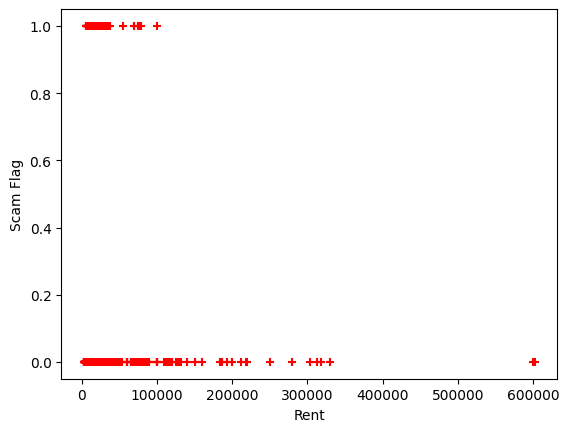

In [8]:
plt.scatter(
    pd.to_numeric(df['Rent'], errors='coerce'),
    df['Scam_Flag'].map({'no': 0, 'yes': 1}),
    marker='+',
    color='red'
)
plt.xlabel('Rent')
plt.ylabel('Scam Flag')

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    df[['Rent']],
    df['Scam_Flag'].map({'no': 0, 'yes': 1}),
    train_size=0.8
)

In [9]:
X_test

,Rent
136,15000
1423,11517
1240,15902
535,10000
683,16000
...,...
687,15000
1287,23314
248,38000
112,15000


In [10]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [11]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [12]:
X_test

,Rent
136,15000
1423,11517
1240,15902
535,10000
683,16000
...,...
687,15000
1287,23314
248,38000
112,15000


In [14]:
y_predicted = model.predict(X_test)

In [15]:
model.predict_proba(X_test)

array([[0.91278774, 0.08721226],
       [0.91250172, 0.08749828],
       [0.91286168, 0.08713832],
       [0.91237688, 0.08762312],
       [0.91286971, 0.08713029],
       [0.91237688, 0.08762312],
       [0.91231922, 0.08768078],
       [0.91266467, 0.08733533],
       [0.91282373, 0.08717627],
       [0.91354797, 0.08645203],
       [0.91400991, 0.08599009],
       [0.912113  , 0.087887  ],
       [0.91319687, 0.08680313],
       [0.9129516 , 0.0870484 ],
       [0.91278774, 0.08721226],
       [0.9127779 , 0.0872221 ],
       [0.91291066, 0.08708934],
       [0.91254143, 0.08745857],
       [0.91274821, 0.08725179],
       [0.91305976, 0.08694024],
       [0.91286971, 0.08713029],
       [0.91237688, 0.08762312],
       [0.91254143, 0.08745857],
       [0.91278774, 0.08721226],
       [0.91322405, 0.08677595],
       [0.91278774, 0.08721226],
       [0.91241286, 0.08758714],
       [0.91250756, 0.08749244],
       [0.91184013, 0.08815987],
       [0.91196426, 0.08803574],
       [0.

In [16]:
model.score(X_test,y_test)

0.9166666666666666

In [17]:
y_predicted

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [18]:
X_test

,Rent
136,15000
1423,11517
1240,15902
535,10000
683,16000
...,...
687,15000
1287,23314
248,38000
112,15000


In [19]:
model.coef_

array([[-1.03005501e-06]])

In [22]:
model.intercept_

array([-2.33270766])

In [23]:
import math
def sigmoid(x):
  return 1 / (1 + math.exp(-x))

In [26]:
def prediction_function(rent):
    z = model.coef_[0][0] * rent + model.intercept_[0]
    y = sigmoid(z)
    return y

In [28]:
rent = 15000
prediction_function(rent)

0.08721225694933359